In [2]:
import pandas as pd
import numpy as np
import scipy.stats as sps
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

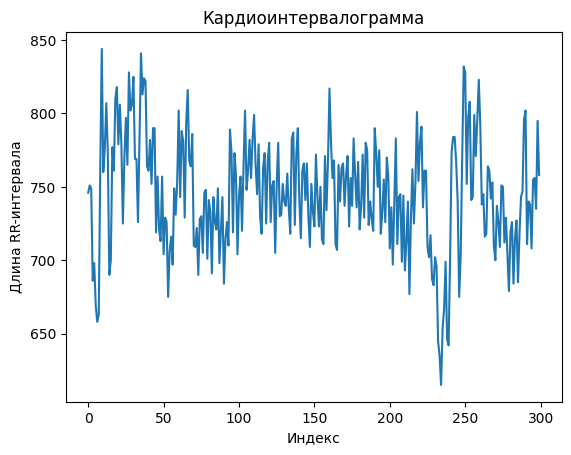

In [3]:
# Загружаем данные из CSV-файла
data = pd.read_csv("/1_f.csv", header=None)

# Извлекаем значения из столбца
values = data.values.flatten()

# Создаем массив индексов
indices = range(len(values))

# Строим график
plt.plot(indices, values)

# Настраиваем заголовки осей
plt.xlabel("Индекс")
plt.ylabel("Длина RR-интервала")

# Добавляем заголовок графика
plt.title("Кардиоинтервалограмма")

# Отображаем график
plt.show()

In [4]:
def find_nn_intervals(rr_intervals):

  # 1. Вычисляем порог для определения экстрасистол
  threshold = np.mean(rr_intervals) * 1.5  # 1.5 - эмпирическое значение

  # 2. Находим NN-интервалы, исключая экстрасистолы
  nn_intervals = []
  for i in range(len(rr_intervals) - 1):
    if rr_intervals[i] < threshold and rr_intervals[i + 1] < threshold:
      nn_intervals.append(rr_intervals[i])

  return np.array(nn_intervals)

In [5]:
def sum_of_squares_difference(arr):

  # Создаем массив разностей
  differences = np.diff(arr)

  # Вычисляем сумму квадратов разностей
  sum_of_squares = np.sum(differences**2)

  return sum_of_squares

In [6]:
#Частота сердечных сокращений
nn_values = find_nn_intervals(values)
chss = 60 * 1000 * len(values) / sum(nn_values)
print("Частота сердечных сокращений: ", chss)

#Среднее значение
median = sum(values)/len(values)
print("Среднее значение: ", median)

#Стандартное отклонение (SDNN)
sdnn = ((1/(len(values)-1))*sum_of_squares_difference(nn_values))**(1/2)
print("Стандартное отклонение (SDNN): ", sdnn)

#Коэффициент вариации (CV)
cv = sdnn/median * 100
print("Коэффициент вариации (CV): ", cv)

#Среднеквадратическую разностную характеристику RMSSD
rmssd = ((1/(len(values)-1))*sum((values-median)**2))**(1/2)
print("Среднеквадратическую разностную характеристику RMSSD: ", rmssd)

Частота сердечных сокращений:  80.8327570257138
Среднее значение:  744.8
Стандартное отклонение (SDNN):  37.33751867764306
Коэффициент вариации (CV):  5.0130932703602396
Среднеквадратическую разностную характеристику RMSSD:  38.697955664030246


In [7]:
intervals = (max(values) - min(values))/50
print(intervals)
count = ((max(values) - min(values))/intervals)
print(count)

4.58
50.0


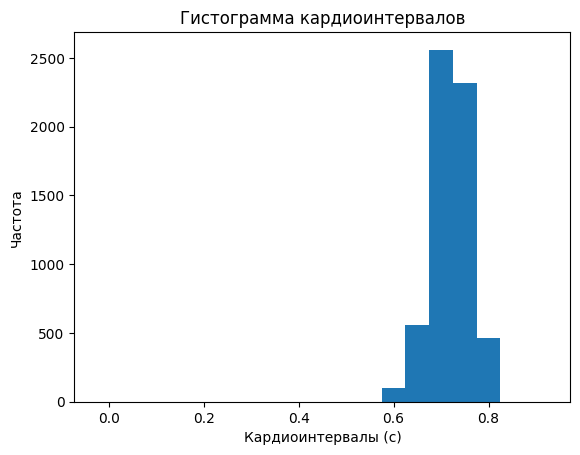

In [8]:
values = values/1000

# Шаг гистограммы (в секундах)
step = 0.05

# Разбиваем кардиоинтервалы на интервалы длиной step
bins = np.arange(0, 1.0, step=step)

# Вычисляем частоту попадания в каждый интервал
frequencies, _ = np.histogram(values, bins=bins)

# Делим частоту на шаг, чтобы получить высоту прямоугольников гистограммы
heights = frequencies / step

# Строим гистограмму
plt.bar(bins[:-1], heights, width=step)
plt.xlabel("Кардиоинтервалы (с)")
plt.ylabel("Частота")
plt.title("Гистограмма кардиоинтервалов")
plt.show()


In [9]:
# Находим максимальное значение частоты
max_frequency = np.max(frequencies)

# Находим индекс интервала с максимальной частотой
max_index = np.argmax(frequencies)

# Вычисляем амплитуду моды
amplitude_of_mode = max_frequency / step

# Вычисляем моду
mode = bins[max_index]

# Вычисляем вариационный размах
max_interval = bins[-1]
min_interval = bins[0]
variation_range = max_interval - min_interval

# Вычисляем индекс напряжения регуляторных систем
index_of_voltage = (amplitude_of_mode - 1) / amplitude_of_mode

# Выводим результаты
print("Амплитуда моды:", amplitude_of_mode)
print("Мода:", mode)
print("Вариационный размах:", variation_range)
print("Индекс напряжения регуляторных систем:", index_of_voltage)


Амплитуда моды: 2560.0
Мода: 0.7000000000000001
Вариационный размах: 0.9500000000000001
Индекс напряжения регуляторных систем: 0.999609375


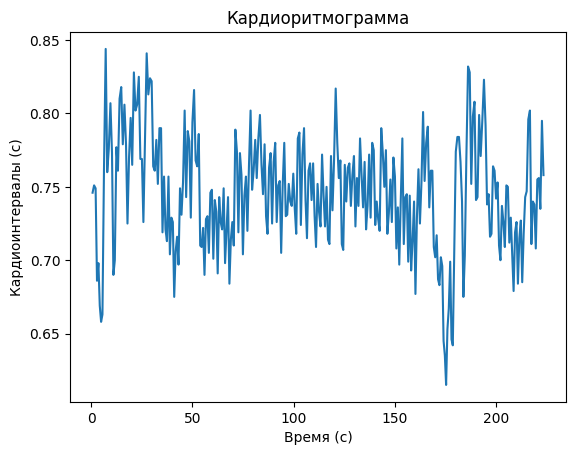

In [10]:
# Создаем массив времени
time = np.cumsum(values)

# Строим кардиоритмограмму
plt.plot(time, values)
plt.xlabel("Время (с)")
plt.ylabel("Кардиоинтервалы (с)")
plt.title("Кардиоритмограмма")
plt.show()


In [15]:
from scipy.interpolate import CubicSpline
from scipy.signal.windows import hann

# Исходные нерегулярные значения длительностей КИ
irreg_time = time
irreg_values = values

# Шаг дискретизации постоянного ряда
dt = 0.25

# Создание интерполятора
interpolator = CubicSpline(irreg_time, irreg_values)

# Создание регулярного ряда
reg_time = np.arange(0, 10.9 + dt, dt)
reg_values = interpolator(reg_time)

# Умножение на окно Хана
window = hann(len(reg_values))
reg_values *= window

# Вывод полученной непрерывной временной функции
print(reg_time)
print(reg_values)


[ 0.    0.25  0.5   0.75  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75
  3.    3.25  3.5   3.75  4.    4.25  4.5   4.75  5.    5.25  5.5   5.75
  6.    6.25  6.5   6.75  7.    7.25  7.5   7.75  8.    8.25  8.5   8.75
  9.    9.25  9.5   9.75 10.   10.25 10.5  10.75 11.  ]
[0.         0.00412194 0.01554438 0.03369768 0.05869021 0.09073799
 0.12961758 0.17417938 0.22195507 0.26888694 0.31069916 0.34908436
 0.39078307 0.44067484 0.49270182 0.53632144 0.56677552 0.58922981
 0.61037716 0.63005097 0.6441391  0.65120023 0.65739401 0.66972787
 0.68835744 0.70700266 0.71922851 0.71793182 0.69615642 0.64935064
 0.58002524 0.50351574 0.43350858 0.37607865 0.32608735 0.27842336
 0.2307307  0.18377412 0.13913927 0.09849871 0.06343147 0.03533874
 0.01526966 0.00366647 0.        ]


In [18]:
from scipy.fft import fft

# Преобразование Фурье
fft_values = fft(reg_values)

print(fft_values)

[ 1.59821061e+01-0.00000000e+00j -8.01507447e+00+8.19980395e-02j
 -2.09454771e-01-6.56982399e-01j  3.19064253e-01+3.78496829e-01j
 -3.31782877e-01-1.01616783e-01j  2.44399013e-01-3.75038111e-02j
  2.57571428e-02+8.74131556e-02j -4.29906476e-02-7.30125762e-02j
 -1.20748640e-02+1.69334533e-02j  3.64799393e-02+3.00304114e-02j
 -1.08198488e-02-1.39080944e-02j  2.20989914e-03+2.16078762e-03j
  8.60895870e-04+4.66354969e-03j  9.29360670e-04+2.09366914e-03j
  6.38616464e-04+7.02800265e-04j  6.11426164e-04+1.63612083e-03j
  1.72350084e-06+4.82597968e-04j  5.09386388e-04+1.27836692e-03j
 -5.81897252e-04+3.45088592e-04j  3.06937399e-04+1.79192126e-04j
  4.26146208e-04+1.35578147e-03j -6.44690919e-04-3.86291674e-04j
  1.76300783e-04-5.41962600e-04j  1.76300783e-04+5.41962600e-04j
 -6.44690919e-04+3.86291674e-04j  4.26146208e-04-1.35578147e-03j
  3.06937399e-04-1.79192126e-04j -5.81897252e-04-3.45088592e-04j
  5.09386388e-04-1.27836692e-03j  1.72350084e-06-4.82597968e-04j
  6.11426164e-04-1.636120

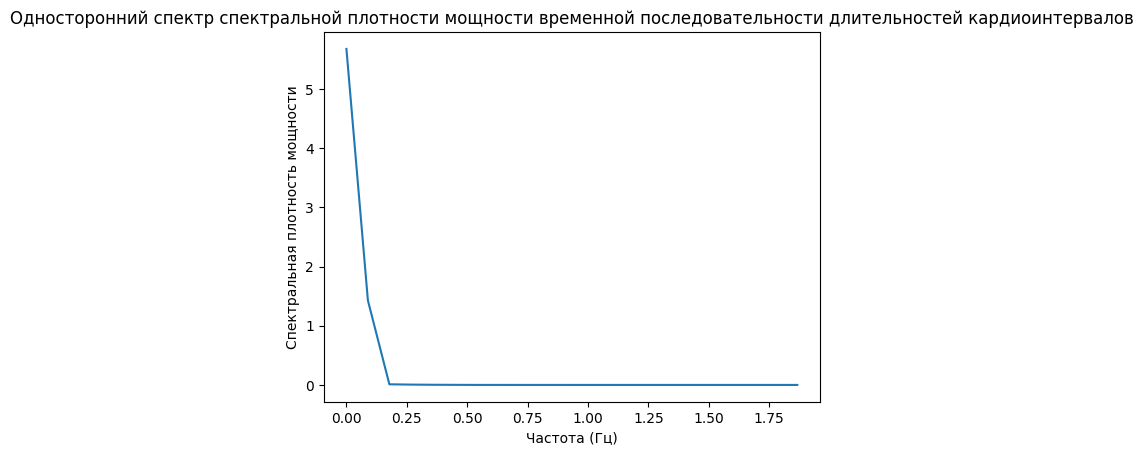

In [42]:
from scipy.fft import fftfreq

# Частоты
frequencies = fftfreq(len(fft_values), d=dt)

# Спектральная мощность
power_spectrum = np.abs(fft_values)**2 / len(fft_values)

# Односторонний спектр
half_power_spectrum = power_spectrum[:len(power_spectrum)//2]
half_frequencies = frequencies[:len(frequencies)//2]

# Построение графика
plt.plot(half_frequencies, half_power_spectrum)
plt.xlabel("Частота (Гц)")
plt.ylabel("Спектральная плотность мощности")
plt.title("Односторонний спектр спектральной плотности мощности временной последовательности длительностей кардиоинтервалов")
plt.show()

In [43]:
frequencies = np.abs(frequencies)

# Диапазоны частот
hf_range = (0.15, 0.4)
lf_range = (0.04, 0.15)
vlf_range = (0.015, 0.04)
ulf_range = (0, 0.015)

# Расчет мощностей спектров в каждом диапазоне частот
hf_power = np.sum(power_spectrum[(frequencies >= hf_range[0]) & (frequencies <= hf_range[1])])
lf_power = np.sum(power_spectrum[(frequencies >= lf_range[0]) & (frequencies <= lf_range[1])])
vlf_power = np.sum(power_spectrum[(frequencies >= vlf_range[0]) & (frequencies <= vlf_range[1])])
ulf_power = np.sum(power_spectrum[(frequencies >= ulf_range[0]) & (frequencies <= ulf_range[1])])

# Минимальное и максимальное значения мощностей спектров
min_power = min(hf_power, lf_power, vlf_power, ulf_power)
max_power = max(hf_power, lf_power, vlf_power, ulf_power)

# Вывод результатов
print("Мощности спектров:")
print("HF:", hf_power)
print("LF:", lf_power)
print("VLF:", vlf_power)
print("ULF:", ulf_power)
print("Минимальное значение:", min_power)
print("Максимальное значение:", max_power)

Мощности спектров:
HF: 0.03737621637400899
LF: 2.855473000750791
VLF: 0.0
ULF: 5.676171424770955
Минимальное значение: 0.0
Максимальное значение: 5.676171424770955


In [45]:
# Суммарная мощность спектра
total_power = hf_power + lf_power + vlf_power + ulf_power

# Мощности спектра в процентах от общего диапазона
hf_percent = hf_power / total_power * 100
lf_percent = lf_power / total_power * 100
vlf_percent = vlf_power / total_power * 100
ulf_percent = ulf_power / total_power * 100

# Вывод результатов
print("Суммарная мощность спектра:", total_power)
print("Мощности спектра в процентах от общего диапазона:")
print("HF:", hf_percent)
print("LF:", lf_percent)
print("VLF:", vlf_percent)
print("ULF:", ulf_percent)

Суммарная мощность спектра: 8.569020641895754
Мощности спектра в процентах от общего диапазона:
HF: 0.4361783911602308
LF: 33.3232130027763
VLF: 0.0
ULF: 66.24060860606347


In [47]:
# Расчет индексов вариабельности сердечного ритма
ic = (ulf_power + vlf_power) / (hf_power + lf_power + vlf_power + ulf_power)
ivv = (lf_power / hf_power) / ((lf_power / hf_power) + 1)
ispa = (hf_power / (hf_power + lf_power + vlf_power + ulf_power)) * 100

# Вывод результатов
print("Индексы вариабельности сердечного ритма:")
print("ИЦ:", ic)
print("ИВВ:", ivv)
print("ИАП:", ispa)

Индексы вариабельности сердечного ритма:
ИЦ: 0.6624060860606348
ИВВ: 0.9870797910403512
ИАП: 0.4361783911602308


In [ ]:
# ИЦ от 0,45 до 0,75 является средним, то есть активность центрального и автономного контура регуляции уравновешена при ИЦ = 0,66
# ИВВ от 0,5 до 1,5 также считается средним, что подтверждает равновесие симпатической и парасимпатической активности
# Норма ИАП - 20-40%, полученное значение чуть больше, что может указывать на повышенную активность подкорковых нервных центров